# Rice Pest CNN: MobileNetV3-Large (v2)

Run the cells top to bottom. Set the runtime to **GPU** first (Runtime > Change runtime type > T4 GPU).

Drive layout expected:
```
MyDrive/rice-pest-cnn/
  dataset/      <- one folder per class (incl. no_pest)
  model/        <- outputs are saved here
  field_test/   <- optional: real field photos, same class folder names (never trained on)
```

In [ ]:
!pip install -q onnx onnxscript onnxruntime imagehash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 754.2/754.2 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.2/343.2 kB 8.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 7.36.2 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.36.2 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have pro

## 1. Setup and config

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, random, json, shutil, copy, time
import numpy as np
import torch

# ---------------- paths ----------------
DRIVE_ROOT  = '/content/drive/MyDrive/rice-pest-cnn'
DATASET_DIR = f'{DRIVE_ROOT}/dataset'
MODEL_DIR   = f'{DRIVE_ROOT}/model'
FIELD_DIR   = f'{DRIVE_ROOT}/field_test'      # optional
SPLIT_DIR   = '/content/rice_pest_data'       # local disk = fast training
os.makedirs(MODEL_DIR, exist_ok=True)

# ---------------- config ----------------
SEED             = 42
IMG_SIZE         = 224
BATCH_SIZE       = 32
SPLIT_RATIOS     = {'train': 0.70, 'val': 0.15, 'test': 0.15}
IMG_EXTS         = ('.jpg', '.jpeg', '.png', '.webp', '.bmp')
REMOVE_DUPLICATES = True     # drop identical / near-identical images before splitting
FORCE_RESPLIT     = False    # True = ignore the saved split and make a new one
USE_BALANCED_SAMPLER = True  # oversample rare classes on the fly (replaces offline augmentation)

PHASE1_EPOCHS, PHASE1_LR, PHASE1_PATIENCE = 12, 1e-3, 4
PHASE2_EPOCHS, PHASE2_LR, PHASE2_PATIENCE = 30, 1e-4, 7
UNFREEZE_LAST_BLOCKS = 6     # how many MobileNet feature blocks to fine-tune in phase 2
LABEL_SMOOTHING      = 0.1

MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

def seed_everything(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
seed_everything()

CLASSES = sorted(
    d for d in os.listdir(DATASET_DIR)
    if os.path.isdir(os.path.join(DATASET_DIR, d)) and not d.startswith('.')
)
NUM_CLASSES = len(CLASSES)
print(f'Found {NUM_CLASSES} classes:')
for c in CLASSES:
    n = len([f for f in os.listdir(os.path.join(DATASET_DIR, c)) if f.lower().endswith(IMG_EXTS)])
    print(f'  - {c}: {n} images')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'\nUsing device: {device}')
if device.type != 'cuda':
    print('WARNING: no GPU. Training will be very slow. Runtime > Change runtime type > T4 GPU.')

Mounted at /content/drive
Found 10 classes:
  - army_worm: 247 images
  - brown_plant_hopper: 618 images
  - golden_apple_snail: 779 images
  - green_leafhopper: 385 images
  - no_pest: 200 images
  - paddy_stem_maggot: 300 images
  - rice_black_bug: 420 images
  - rice_bugs: 496 images
  - rice_leaf_caterpillar: 299 images
  - rice_stem_borer: 756 images

Using device: cuda


## 2. Clean duplicates and make a reproducible split

In [ ]:
from PIL import Image
import imagehash

CACHE_PATH    = f'{MODEL_DIR}/hash_cache.json'
MANIFEST_PATH = f'{MODEL_DIR}/split_manifest.json'

def list_images(cls):
    folder = os.path.join(DATASET_DIR, cls)
    return sorted(f for f in os.listdir(folder) if f.lower().endswith(IMG_EXTS))

def load_hash_cache():
    return json.load(open(CACHE_PATH)) if os.path.exists(CACHE_PATH) else {}

def deduplicate():
    # perceptual-hash equality: catches exact copies and re-saved/resized copies
    cache = load_hash_cache()
    seen, kept = {}, {c: [] for c in CLASSES}
    dropped, conflicts = 0, []
    for cls in CLASSES:
        for f in list_images(cls):
            key = f'{cls}/{f}'
            if key not in cache:
                try:
                    with Image.open(os.path.join(DATASET_DIR, cls, f)) as im:
                        cache[key] = str(imagehash.phash(im.convert('RGB')))
                except Exception as e:
                    print('Skipping unreadable image:', key, e)
                    continue
            h = cache[key]
            if h in seen:
                dropped += 1
                if seen[h] != cls:
                    conflicts.append((key, seen[h]))
                continue
            seen[h] = cls
            kept[cls].append(f)
    json.dump(cache, open(CACHE_PATH, 'w'))
    print(f'Duplicates removed: {dropped}')
    if conflicts:
        print(f'WARNING: {len(conflicts)} images also appear in a different class (possible label noise). Examples:')
        for k, other in conflicts[:10]:
            print(f'   {k}  <->  {other}')
    return kept

def make_manifest():
    if REMOVE_DUPLICATES:
        files = deduplicate()
    else:
        files = {c: list_images(c) for c in CLASSES}
    rng = random.Random(SEED)
    manifest = {'classes': CLASSES, 'splits': {s: {} for s in SPLIT_RATIOS}}
    for cls in CLASSES:
        imgs = files[cls][:]
        rng.shuffle(imgs)
        n = len(imgs)
        n_train = int(n * SPLIT_RATIOS['train'])
        n_val   = int(n * SPLIT_RATIOS['val'])
        manifest['splits']['train'][cls] = imgs[:n_train]
        manifest['splits']['val'][cls]   = imgs[n_train:n_train + n_val]
        manifest['splits']['test'][cls]  = imgs[n_train + n_val:]
    json.dump(manifest, open(MANIFEST_PATH, 'w'))
    return manifest

def manifest_is_valid(m):
    if m.get('classes') != CLASSES:
        return False
    for split in m['splits'].values():
        for cls, fs in split.items():
            if any(not os.path.exists(os.path.join(DATASET_DIR, cls, f)) for f in fs[:20]):
                return False
    return True

def local_split_matches(m):
    for split, per_cls in m['splits'].items():
        for cls, fs in per_cls.items():
            p = os.path.join(SPLIT_DIR, split, cls)
            if not os.path.isdir(p) or len(os.listdir(p)) != len(fs):
                return False
    return True

manifest = None
if os.path.exists(MANIFEST_PATH) and not FORCE_RESPLIT:
    m = json.load(open(MANIFEST_PATH))
    if manifest_is_valid(m):
        manifest = m
        print('Reusing saved split (same train/val/test as previous runs).')
    else:
        print('Saved split does not match the current dataset. Creating a new one.')
if manifest is None:
    manifest = make_manifest()

if not local_split_matches(manifest):
    shutil.rmtree(SPLIT_DIR, ignore_errors=True)
    for split, per_cls in manifest['splits'].items():
        for cls, fs in per_cls.items():
            dest = os.path.join(SPLIT_DIR, split, cls)
            os.makedirs(dest, exist_ok=True)
            for f in fs:
                shutil.copy(os.path.join(DATASET_DIR, cls, f), os.path.join(dest, f))
    print('Copied split to local disk.')

print('\nSplit sizes (train / val / test):')
for cls in CLASSES:
    t, v, s = (len(manifest['splits'][k][cls]) for k in ('train', 'val', 'test'))
    print(f'  {cls}: {t} / {v} / {s}')

Duplicates removed: 701
   rice_bugs/IMG_20261002_205456_023.jpg  <->  rice_black_bug
   rice_bugs/IMG_20261002_205500_840.jpg  <->  rice_black_bug
   rice_bugs/IMG_20261002_205503_485.jpg  <->  rice_black_bug
Copied split to local disk.

Split sizes (train / val / test):
  army_worm: 158 / 34 / 35
  brown_plant_hopper: 420 / 90 / 91
  golden_apple_snail: 429 / 92 / 93
  green_leafhopper: 193 / 41 / 43
  no_pest: 140 / 30 / 30
  paddy_stem_maggot: 134 / 28 / 30
  rice_black_bug: 281 / 60 / 61
  rice_bugs: 334 / 71 / 73
  rice_leaf_caterpillar: 142 / 30 / 31
  rice_stem_borer: 423 / 90 / 92


## 3. Data loaders (augmentation happens on the fly, no augmented files are saved)

In [ ]:
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, WeightedRandomSampler

train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.6, 1.0), ratio=(0.75, 1.33)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(25),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.25, hue=0.03),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 1.5))], p=0.2),  # camera blur
    transforms.TrivialAugmentWide(),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.15)),   # partial occlusion (leaves, dirt)
])
eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

train_dataset = datasets.ImageFolder(os.path.join(SPLIT_DIR, 'train'), transform=train_transforms)
val_dataset   = datasets.ImageFolder(os.path.join(SPLIT_DIR, 'val'),   transform=eval_transforms)
test_dataset  = datasets.ImageFolder(os.path.join(SPLIT_DIR, 'test'),  transform=eval_transforms)

CLASS_NAMES = [c for c, _ in sorted(train_dataset.class_to_idx.items(), key=lambda kv: kv[1])]
assert CLASS_NAMES == CLASSES
assert val_dataset.classes == CLASS_NAMES and test_dataset.classes == CLASS_NAMES

def seed_worker(worker_id):
    s = torch.initial_seed() % 2**32
    np.random.seed(s); random.seed(s)

g = torch.Generator(); g.manual_seed(SEED)

train_counts = np.bincount(train_dataset.targets, minlength=NUM_CLASSES)
if USE_BALANCED_SAMPLER:
    sample_weights = [1.0 / train_counts[t] for t in train_dataset.targets]
    sampler = WeightedRandomSampler(sample_weights, num_samples=len(train_dataset), replacement=True, generator=g)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2,
                              pin_memory=True, worker_init_fn=seed_worker, persistent_workers=True)
else:
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2,
                              pin_memory=True, worker_init_fn=seed_worker, generator=g, persistent_workers=True)

val_loader  = DataLoader(val_dataset,  batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

print('Class mapping and train counts:')
for i, n in enumerate(CLASS_NAMES):
    print(f'  {i}: {n} ({train_counts[i]} train images)')

Class mapping and train counts:
  0: army_worm (158 train images)
  1: brown_plant_hopper (420 train images)
  2: golden_apple_snail (429 train images)
  3: green_leafhopper (193 train images)
  4: no_pest (140 train images)
  5: paddy_stem_maggot (134 train images)
  6: rice_black_bug (281 train images)
  7: rice_bugs (334 train images)
  8: rice_leaf_caterpillar (142 train images)
  9: rice_stem_borer (423 train images)


## 4. Model: MobileNetV3-Large

In [ ]:
model = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.IMAGENET1K_V1)

# freeze the backbone for phase 1
for p in model.features.parameters():
    p.requires_grad = False

in_features = model.classifier[3].in_features
model.classifier[2] = nn.Dropout(p=0.3)
model.classifier[3] = nn.Linear(in_features, NUM_CLASSES)
model = model.to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model ready. Trainable params (phase 1): {trainable:,}')

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 165MB/s]


Model ready. Trainable params (phase 1): 1,242,890


## 5. Training utilities

In [ ]:
from torch.amp import autocast, GradScaler
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
import torch.optim as optim
from sklearn.metrics import f1_score

criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
use_amp = device.type == 'cuda'

def set_train_mode():
    model.train()
    # BatchNorm layers of frozen blocks must keep their ImageNet statistics
    for m in model.modules():
        if isinstance(m, nn.BatchNorm2d) and not m.weight.requires_grad:
            m.eval()

def run_epoch(loader, train, optimizer=None, scaler=None):
    if train:
        set_train_mode()
    else:
        model.eval()
    total_loss, correct, total = 0.0, 0, 0
    preds_all, labels_all = [], []
    with torch.set_grad_enabled(train):
        for inputs, labels in loader:
            inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            with autocast(device_type=device.type, enabled=use_amp):
                outputs = model(inputs)
                loss = criterion(outputs, labels)
            if train:
                optimizer.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                scaler.step(optimizer)
                scaler.update()
            preds = outputs.argmax(1)
            total_loss += loss.item() * inputs.size(0)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            preds_all.append(preds.cpu().numpy()); labels_all.append(labels.cpu().numpy())
    macro_f1 = f1_score(np.concatenate(labels_all), np.concatenate(preds_all), average='macro')
    return total_loss / total, 100.0 * correct / total, 100.0 * macro_f1

def train_phase(phase_name, epochs, param_groups, patience, ckpt_name, best_f1_init=-1.0):
    optimizer = optim.AdamW(param_groups, weight_decay=1e-4)
    warmup = LinearLR(optimizer, start_factor=0.1, total_iters=1)
    cosine = CosineAnnealingLR(optimizer, T_max=max(1, epochs - 1))
    scheduler = SequentialLR(optimizer, [warmup, cosine], milestones=[1])
    scaler = GradScaler('cuda', enabled=use_amp)

    best_f1, best_state, no_improve = best_f1_init, copy.deepcopy(model.state_dict()), 0
    history = []
    print(f'\n=== {phase_name}: up to {epochs} epochs, patience {patience} ===')
    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc, _      = run_epoch(train_loader, True, optimizer, scaler)
        va_loss, va_acc, va_f1  = run_epoch(val_loader, False)
        scheduler.step()
        history.append(dict(train_loss=tr_loss, train_acc=tr_acc, val_loss=va_loss, val_acc=va_acc, val_f1=va_f1))

        improved = va_f1 > best_f1
        if improved:
            best_f1, no_improve = va_f1, 0
            best_state = copy.deepcopy(model.state_dict())
            # saved to Drive immediately so a disconnect never loses the best weights
            torch.save({'model_state_dict': best_state, 'class_names': CLASS_NAMES,
                        'epoch': epoch, 'val_macro_f1': va_f1}, f'{MODEL_DIR}/{ckpt_name}')
        else:
            no_improve += 1

        print(f'Epoch {epoch:2d}/{epochs} | train loss {tr_loss:.3f} acc {tr_acc:.1f}% | '
              f'val loss {va_loss:.3f} acc {va_acc:.1f}% F1 {va_f1:.1f}% | {time.time()-t0:.0f}s {"* best" if improved else ""}')
        if no_improve >= patience:
            print(f'No improvement for {patience} epochs. Stopping {phase_name} early.')
            break

    model.load_state_dict(best_state)
    return best_f1, history

## 6. Train (phase 1: head only, phase 2: fine-tune last blocks)

In [ ]:
# Phase 1: classifier head only
head_params = [p for p in model.classifier.parameters() if p.requires_grad]
phase1_f1, phase1_history = train_phase(
    'Phase 1 (head only)', PHASE1_EPOCHS,
    [{'params': head_params, 'lr': PHASE1_LR}],
    PHASE1_PATIENCE, 'best_phase1.pth')

# Phase 2: unfreeze the last blocks, lower LR for the backbone
backbone_params = []
n_blocks = len(model.features)
for name, p in model.features.named_parameters():
    if int(name.split('.')[0]) >= n_blocks - UNFREEZE_LAST_BLOCKS:
        p.requires_grad = True
        backbone_params.append(p)

print('\nTrainable params (phase 2):', sum(p.numel() for p in model.parameters() if p.requires_grad))
phase2_f1, phase2_history = train_phase(
    'Phase 2 (fine-tune)', PHASE2_EPOCHS,
    [{'params': backbone_params, 'lr': PHASE2_LR},
     {'params': head_params,     'lr': PHASE2_LR * 3}],
    PHASE2_PATIENCE, 'best_phase2.pth', best_f1_init=phase1_f1)

torch.save({'model_state_dict': model.state_dict(), 'class_names': CLASS_NAMES},
           f'{MODEL_DIR}/best_model.pth')
print(f'\nBest validation macro-F1: {max(phase1_f1, phase2_f1):.2f}%  (saved to {MODEL_DIR}/best_model.pth)')


=== Phase 1 (head only): up to 12 epochs, patience 4 ===
Epoch  1/12 | train loss 1.461 acc 68.7% | val loss 0.903 acc 88.9% F1 88.5% | 258s * best
Epoch  2/12 | train loss 0.783 acc 91.1% | val loss 0.716 acc 93.6% F1 93.8% | 234s * best
Epoch  3/12 | train loss 0.678 acc 95.0% | val loss 0.630 acc 95.8% F1 95.6% | 235s * best
Epoch  4/12 | train loss 0.658 acc 95.9% | val loss 0.636 acc 96.1% F1 96.0% | 248s * best
Epoch  5/12 | train loss 0.625 acc 97.1% | val loss 0.628 acc 95.9% F1 95.8% | 235s 
Epoch  6/12 | train loss 0.620 acc 97.3% | val loss 0.608 acc 97.7% F1 97.4% | 235s * best
Epoch  7/12 | train loss 0.611 acc 97.8% | val loss 0.607 acc 96.8% F1 96.3% | 241s 
Epoch  8/12 | train loss 0.606 acc 97.8% | val loss 0.594 acc 98.1% F1 97.9% | 239s * best
Epoch  9/12 | train loss 0.599 acc 97.9% | val loss 0.601 acc 97.2% F1 97.0% | 242s 
Epoch 10/12 | train loss 0.600 acc 98.0% | val loss 0.601 acc 96.6% F1 96.4% | 233s 
Epoch 11/12 | train loss 0.595 acc 98.1% | val loss 0.59

## 7. Training curves

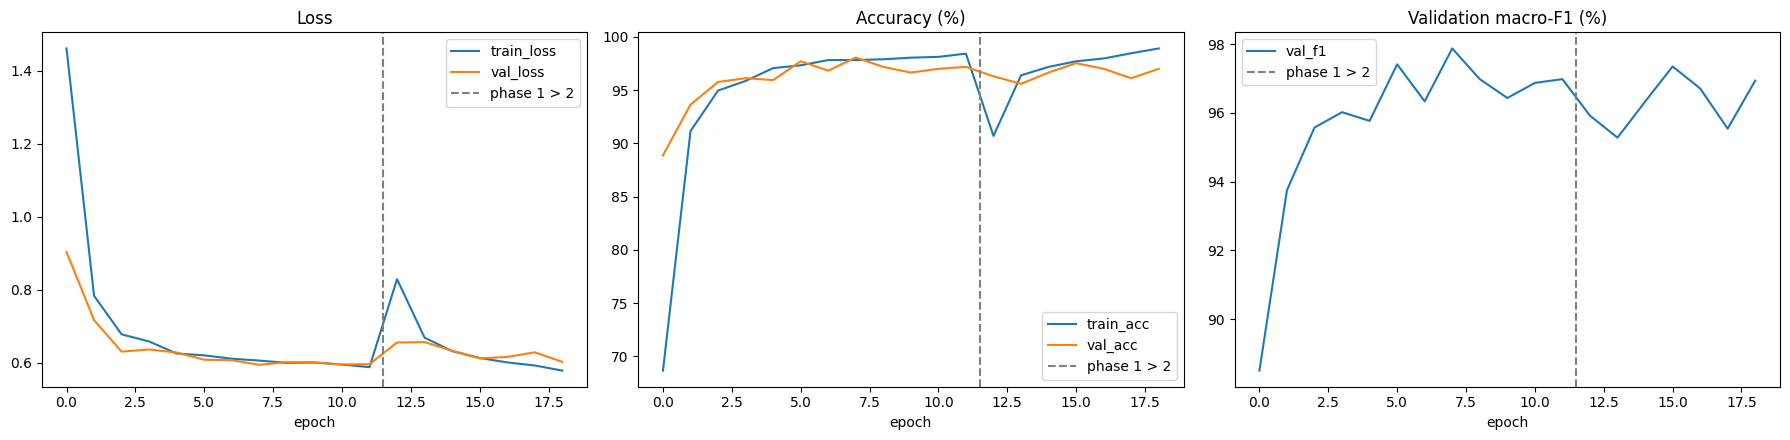

In [ ]:
import matplotlib.pyplot as plt

hist = phase1_history + phase2_history
p1 = len(phase1_history)
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for ax, (keys, title) in zip(axes, [(('train_loss', 'val_loss'), 'Loss'),
                                    (('train_acc', 'val_acc'), 'Accuracy (%)'),
                                    (('val_f1',), 'Validation macro-F1 (%)')]):
    for k in keys:
        ax.plot([h[k] for h in hist], label=k)
    ax.axvline(p1 - 0.5, color='gray', linestyle='--', label='phase 1 > 2')
    ax.set_title(title); ax.set_xlabel('epoch'); ax.legend()
plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Evaluation (validation picks the confidence threshold, test is only reported)

FINAL TEST RESULTS (with flip TTA)
                       precision    recall  f1-score   support

            army_worm     1.0000    1.0000    1.0000        35
   brown_plant_hopper     0.9888    0.9670    0.9778        91
   golden_apple_snail     0.9789    1.0000    0.9894        93
     green_leafhopper     0.9767    0.9767    0.9767        43
              no_pest     1.0000    1.0000    1.0000        30
    paddy_stem_maggot     0.9333    0.9333    0.9333        30
       rice_black_bug     1.0000    0.9836    0.9917        61
            rice_bugs     1.0000    1.0000    1.0000        73
rice_leaf_caterpillar     0.9375    0.9677    0.9524        31
      rice_stem_borer     0.9891    0.9891    0.9891        92

             accuracy                         0.9845       579
            macro avg     0.9804    0.9818    0.9810       579
         weighted avg     0.9846    0.9845    0.9845       579



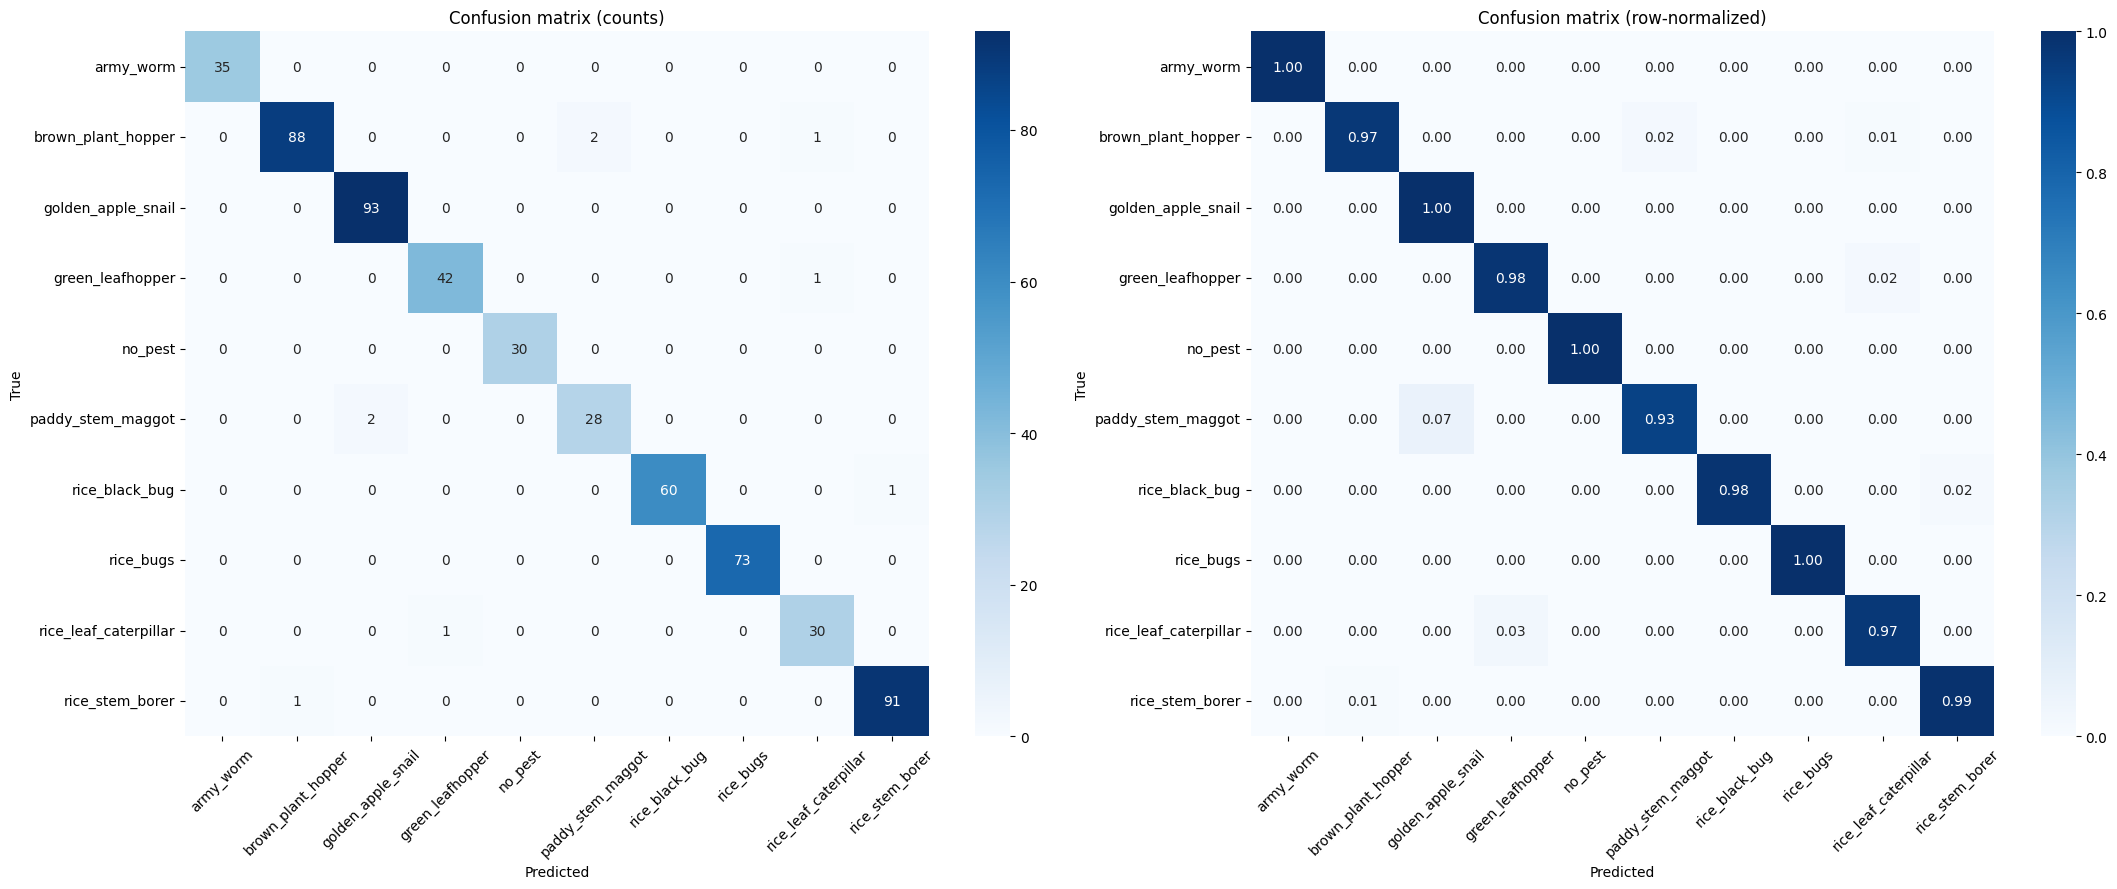


Most confused class pairs (true -> predicted):
  paddy_stem_maggot -> golden_apple_snail: 2
  brown_plant_hopper -> paddy_stem_maggot: 2
  rice_stem_borer -> brown_plant_hopper: 1
  rice_leaf_caterpillar -> green_leafhopper: 1
  rice_black_bug -> rice_stem_borer: 1
  green_leafhopper -> rice_leaf_caterpillar: 1
  brown_plant_hopper -> rice_leaf_caterpillar: 1

Confidence threshold chosen on validation (kept-accuracy >= 97%): 0.4
Test set at each threshold:
  thr    coverage   accuracy-on-kept
  0.40     98.4%      99.5%
  0.50     97.2%      99.8%
  0.60     94.8%     100.0%
  0.70     92.2%     100.0%
  0.80     87.0%     100.0%
  0.90     61.0%     100.0%

In the app: if top confidence < threshold, show "unclear, retake photo" instead of a pest name.


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

@torch.no_grad()
def predict_probs(loader, tta=True):
    model.eval()
    probs_all, labels_all = [], []
    for inputs, labels in loader:
        inputs = inputs.to(device)
        with autocast(device_type=device.type, enabled=use_amp):
            p = torch.softmax(model(inputs).float(), dim=1)
            if tta:
                p = (p + torch.softmax(model(torch.flip(inputs, dims=[3])).float(), dim=1)) / 2
        probs_all.append(p.cpu().numpy()); labels_all.append(labels.numpy())
    return np.concatenate(probs_all), np.concatenate(labels_all)

val_probs,  val_labels  = predict_probs(val_loader)
test_probs, test_labels = predict_probs(test_loader)
test_preds = test_probs.argmax(1)

print('=' * 70)
print('FINAL TEST RESULTS (with flip TTA)')
print('=' * 70)
print(classification_report(test_labels, test_preds, target_names=CLASS_NAMES, digits=4))

cm = confusion_matrix(test_labels, test_preds)
cm_norm = cm / cm.sum(axis=1, keepdims=True)
fig, axes = plt.subplots(1, 2, figsize=(22, 9))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title('Confusion matrix (counts)')
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title('Confusion matrix (row-normalized)')
for ax in axes:
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nMost confused class pairs (true -> predicted):')
off = [(cm[i, j], CLASS_NAMES[i], CLASS_NAMES[j]) for i in range(NUM_CLASSES) for j in range(NUM_CLASSES) if i != j and cm[i, j] > 0]
for n, a, b in sorted(off, reverse=True)[:8]:
    print(f'  {a} -> {b}: {n}')

# ---- confidence threshold (chosen on VALIDATION data only) ----
def threshold_table(probs, labels, grid):
    conf, pred = probs.max(1), probs.argmax(1)
    rows = []
    for t in grid:
        keep = conf >= t
        cov = keep.mean()
        acc = (pred[keep] == labels[keep]).mean() if keep.any() else float('nan')
        rows.append((t, cov, acc))
    return rows

grid = [0.40, 0.50, 0.60, 0.70, 0.80, 0.90]
TARGET_ACC = 0.97
CONF_THRESHOLD = 0.60
for t, cov, acc in threshold_table(val_probs, val_labels, grid):
    if acc >= TARGET_ACC:
        CONF_THRESHOLD = t
        break

print(f'\nConfidence threshold chosen on validation (kept-accuracy >= {TARGET_ACC:.0%}): {CONF_THRESHOLD}')
print('Test set at each threshold:')
print('  thr    coverage   accuracy-on-kept')
for t, cov, acc in threshold_table(test_probs, test_labels, grid):
    print(f'  {t:.2f}   {cov:7.1%}   {acc:8.1%}')
print('\nIn the app: if top confidence < threshold, show "unclear, retake photo" instead of a pest name.')

## 9. Real field photos (optional, but the most honest accuracy estimate)

In [ ]:
from torch.utils.data import Dataset

class FieldSet(Dataset):
    def __init__(self, root):
        self.samples = []
        for cls in sorted(os.listdir(root)):
            cdir = os.path.join(root, cls)
            if cls in CLASS_NAMES and os.path.isdir(cdir):
                for f in os.listdir(cdir):
                    if f.lower().endswith(IMG_EXTS):
                        self.samples.append((os.path.join(cdir, f), CLASS_NAMES.index(cls)))
    def __len__(self): return len(self.samples)
    def __getitem__(self, i):
        path, y = self.samples[i]
        return eval_transforms(Image.open(path).convert('RGB')), y

if os.path.isdir(FIELD_DIR) and len(FieldSet(FIELD_DIR)) > 0:
    field_ds = FieldSet(FIELD_DIR)
    field_loader = DataLoader(field_ds, batch_size=32, shuffle=False, num_workers=2)
    f_probs, f_labels = predict_probs(field_loader)
    f_preds = f_probs.argmax(1)
    print(f'Field photos: {len(field_ds)}  |  accuracy: {(f_preds == f_labels).mean():.1%}')
    present = sorted(set(f_labels.tolist()))
    print(classification_report(f_labels, f_preds, labels=present,
                                target_names=[CLASS_NAMES[i] for i in present], digits=3, zero_division=0))
else:
    print(f'No field photos found at {FIELD_DIR}. Skipping.')
    print('Create that folder with the same class sub-folders, add real photos from your camera, and re-run this cell.')

No field photos found at /content/drive/MyDrive/rice-pest-cnn/field_test. Skipping.
Create that folder with the same class sub-folders, add real photos from your camera, and re-run this cell.


## 10. Export to ONNX and verify

In [ ]:
import onnx, onnxruntime as ort

onnx_path = '/content/rice_pest_model.onnx'
model.eval()
dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)

torch.onnx.export(
    model, dummy, onnx_path,
    export_params=True, opset_version=13,
    input_names=['input'], output_names=['output'],
    dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}},
    dynamo=False,
)

onnx.checker.check_model(onnx.load(onnx_path, load_external_data=False))
size_mb = os.path.getsize(onnx_path) / (1024 * 1024)
print(f'File size: {size_mb:.1f} MB')
assert size_mb > 15, f'File suspiciously small ({size_mb:.1f} MB), export likely broken, do not deploy'

# parity check: ONNX Runtime output must match PyTorch on real test images
sess = ort.InferenceSession(onnx_path, providers=['CPUExecutionProvider'])
xb, _ = next(iter(test_loader))
with torch.no_grad():
    torch_out = model(xb.to(device)).float().cpu().numpy()
onnx_out = sess.run(None, {'input': xb.numpy()})[0]
max_diff = np.abs(torch_out - onnx_out).max()
print(f'Max |PyTorch - ONNX| logit difference: {max_diff:.5f}')
assert max_diff < 1e-2, 'ONNX output does not match PyTorch, do not deploy'
assert (torch_out.argmax(1) == onnx_out.argmax(1)).all()

shutil.copy(onnx_path, f'{MODEL_DIR}/rice_pest_model.onnx')
torch.save({'model_state_dict': model.state_dict(), 'class_names': CLASS_NAMES},
           f'{MODEL_DIR}/rice_pest_classifier_final.pth')

# everything the app needs to reproduce preprocessing and decode the output
meta = {
    'class_names': CLASS_NAMES,
    'input_size': IMG_SIZE,
    'input_layout': 'NCHW, RGB, float32, pixels scaled to 0-1 then normalized',
    'mean': MEAN, 'std': STD,
    'output': 'raw logits (apply softmax in the app)',
    'confidence_threshold': float(CONF_THRESHOLD),
    'test_accuracy': float((test_preds == test_labels).mean()),
}
json.dump(meta, open(f'{MODEL_DIR}/model_meta.json', 'w'), indent=2)
print(f'\nSaved to {MODEL_DIR}: rice_pest_model.onnx, rice_pest_classifier_final.pth, model_meta.json')

/tmp/ipykernel_7157/3222876679.py:7: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


File size: 16.1 MB
Max |PyTorch - ONNX| logit difference: 0.00001

Saved to /content/drive/MyDrive/rice-pest-cnn/model: rice_pest_model.onnx, rice_pest_classifier_final.pth, model_meta.json
